In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [2]:
data_train_path = 'Fruits_Vegetables/train'
data_test_path = 'Fruits_Vegetables/test'
data_val_path = 'Fruits_Vegetables/validation'

In [3]:
img_width = 180
img_height =180 

In [4]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32,
    validation_split=False)

Found 3115 files belonging to 36 classes.


In [5]:
data_cat = data_train.class_names

In [6]:
data_cat

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

In [7]:
data_val = tf.keras.utils.image_dataset_from_directory(data_val_path,
                                                       image_size=(img_height,img_width),
                                                       batch_size=32,
                                                        shuffle=False,
                                                       validation_split=False)

Found 351 files belonging to 36 classes.


In [8]:
data_test = tf.keras.utils.image_dataset_from_directory(
data_test_path,
    image_size=(img_height,img_width),
    shuffle=False,
    batch_size=32,
    validation_split=False
)

Found 359 files belonging to 36 classes.


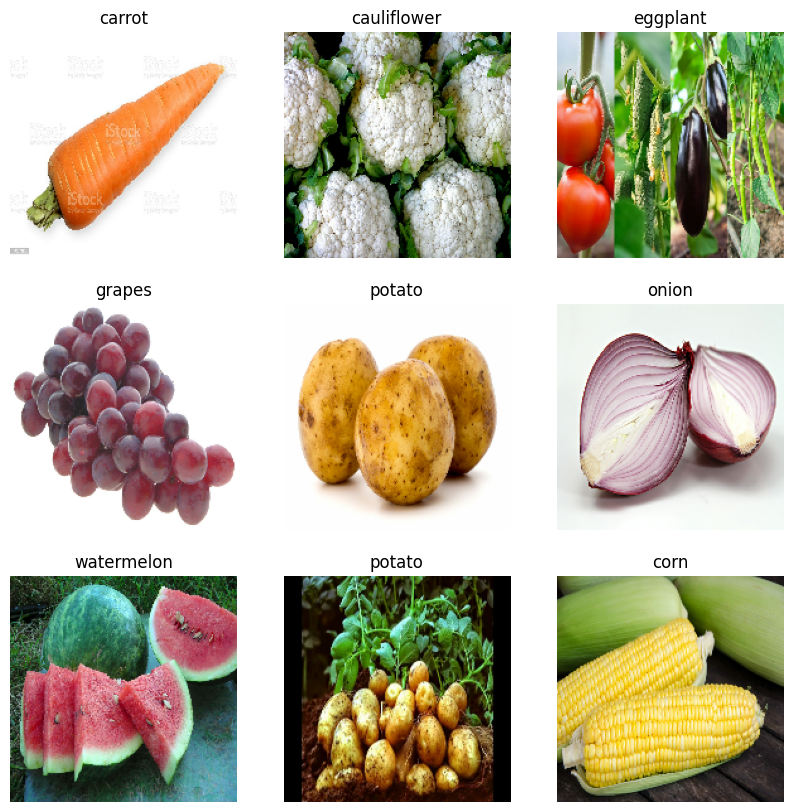

In [9]:
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [10]:
from tensorflow.keras.models import Sequential

In [11]:
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3, padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_cat))
                  
])

In [12]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [13]:
epochs_size = 25
history = model.fit(data_train, validation_data=data_val, epochs=epochs_size)

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 45s 432ms/step - accuracy: 0.1008 - loss: 3.3134 - val_accuracy: 0.3561 - val_loss: 2.2590
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 429ms/step - accuracy: 0.3400 - loss: 2.2881 - val_accuracy: 0.7464 - val_loss: 1.1778
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 409ms/step - accuracy: 0.5634 - loss: 1.5411 - val_accuracy: 0.8746 - val_loss: 0.5740
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 409ms/step - accuracy: 0.7676 - loss: 0.8167 - val_accuracy: 0.9231 - val_loss: 0.3805
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 377ms/step - accuracy: 0.8918 - loss: 0.4090 - val_accuracy: 0.9402 - val_loss: 0.3135
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 37s 378ms/step - accuracy: 0.9435 - loss: 0.2420 - val_accuracy: 0.9487 - val_loss: 0.3335
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 37s 372ms/step - accuracy: 0.9673 - loss: 0.1754 - val_accuracy: 0.9487 - val_loss: 0.2738
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 381ms/step - accuracy: 0.9778 - loss: 0.1373 - val_accu

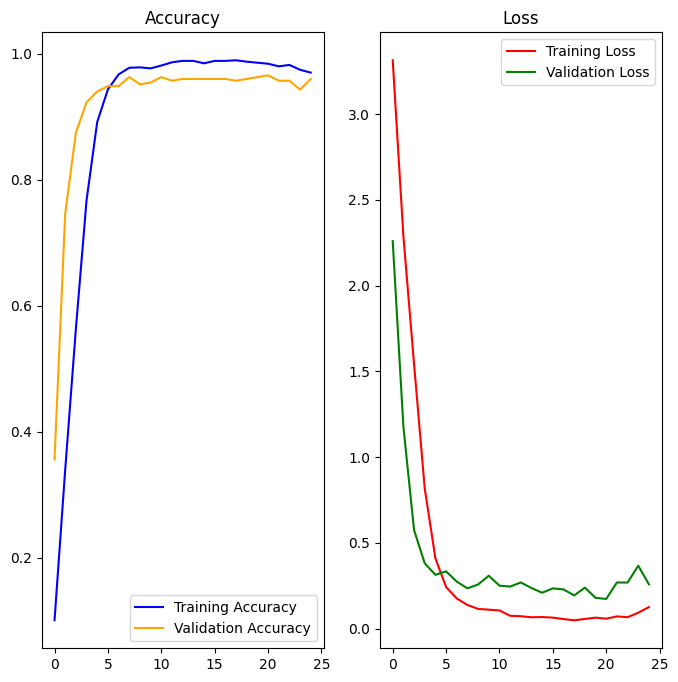

In [17]:
# epochs_range = range(epochs_size)
# plt.figure(figsize=(8,8))
# plt.subplot(1,2,1)
# plt.plot(epochs_range,history.history['accuracy'],label = 'Training Accuracy',color='blue')
# plt.plot(epochs_range, history.history['val_accuracy'],label = 'Validation Accuracy',color='orange')
# plt.title('Accuracy')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.legend()

# plt.subplot(1,2,2)
# plt.plot(epochs_range,history.history['loss'],label = 'Training Loss',color='red')
# plt.plot(epochs_range, history.history['val_loss'],label = 'Validation Loss',color='green')
# plt.title('Loss')

epochs_range = range(epochs_size)
plt.figure(figsize=(8,8))

plt.subplot(1,2,1)
plt.plot(epochs_range, history.history['accuracy'], color='blue', label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], color='orange', label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, history.history['loss'], color='red', label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], color='green', label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss')

plt.show()

In [23]:
image = 'cab.jpg'
image = tf.keras.utils.load_img(image, target_size=(img_height,img_width))
img_arr = tf.keras.utils.array_to_img(image)
img_bat=tf.expand_dims(img_arr,0)

In [24]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


In [25]:
score = tf.nn.softmax(predict)

In [26]:
print('Veg/Fruit in image is {} with accuracy of {:0.2f}'.format(data_cat[np.argmax(score)],np.max(score)*100))

Veg/Fruit in image is cabbage with accuracy of 55.09


In [27]:
model.save('Image_classify.keras')